In [17]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn import tree

In [2]:
df = pd.read_excel("data/dados_cerveja_nota.xlsx")
df.head()

,id,cerveja,nota
0,1,1,0.75
1,2,1,3.00
2,3,2,1.75
3,4,3,1.75
4,5,4,4.20


In [5]:
X = df[['cerveja']]
y = df['nota']
X, y

(    cerveja
 0         1
 1         1
 2         2
 3         3
 4         4
 5         4
 6         5
 7         6
 8         6
 9         7
 10        8
 11        8
 12        9
 13        9
 14        9,
 0      0.75
 1      3.00
 2      1.75
 3      1.75
 4      4.20
 5      6.50
 6      2.90
 7      6.20
 8      7.00
 9      6.20
 10     8.50
 11    10.00
 12     8.60
 13     9.90
 14    10.00
 Name: nota, dtype: float64)

In [6]:
reg = linear_model.LinearRegression()

reg.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
a, b = reg.intercept_, reg.coef_[0]
print(a, b)

0.151612903225808 1.0362903225806448


In [26]:
predict_reg = reg.predict(X.drop_duplicates())

arvore_full = tree.DecisionTreeRegressor(random_state=42)
arvore_full.fit(X, y)

predict_arvore_full = arvore_full.predict(X.drop_duplicates())

arvore_d2 = tree.DecisionTreeRegressor(random_state=42, max_depth=2)
arvore_d2.fit(X, y)

predict_arvore_d2 = arvore_d2.predict(X.drop_duplicates())

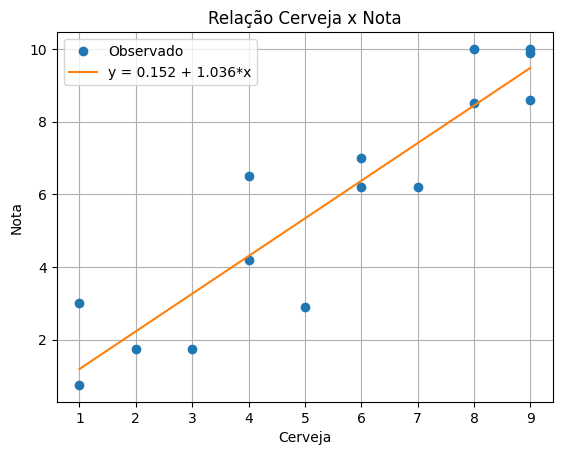

In [ ]:
plt.plot(X['cerveja'], y, 'o')
plt.grid(True)
plt.title('Relação Cerveja x Nota')
plt.xlabel("Cerveja")
plt.ylabel("Nota")

plt.plot(X.drop_duplicates()['cerveja'], predict_reg)


plt.legend(['Observado', f'y = {a:.3f} + {b:.3f}*x'])
plt.show()

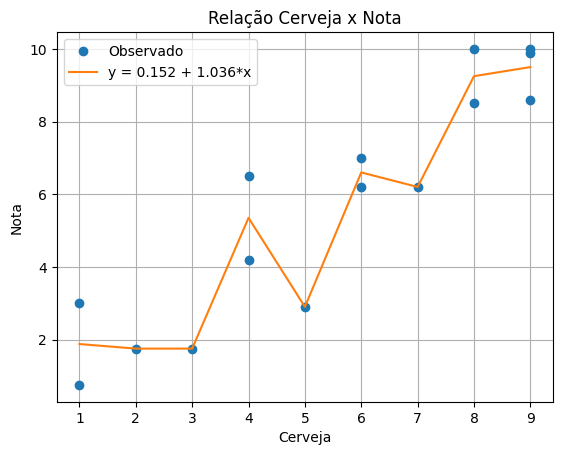

In [22]:
plt.plot(X['cerveja'], y, 'o')
plt.grid(True)
plt.title('Relação Cerveja x Nota')
plt.xlabel("Cerveja")
plt.ylabel("Nota")

plt.plot(X.drop_duplicates()['cerveja'], predict_arvore_full)

plt.legend(['Observado', f'y = {a:.3f} + {b:.3f}*x'])
plt.show()

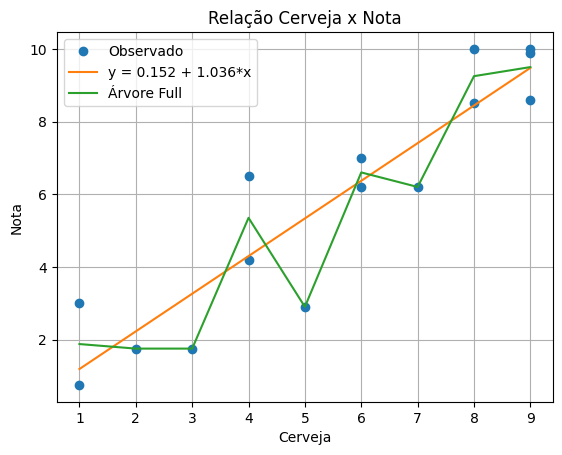

In [23]:
plt.plot(X['cerveja'], y, 'o')
plt.grid(True)
plt.title('Relação Cerveja x Nota')
plt.xlabel("Cerveja")
plt.ylabel("Nota")

plt.plot(X.drop_duplicates()['cerveja'], predict_reg)
plt.plot(X.drop_duplicates()['cerveja'], predict_arvore_full)

plt.legend(['Observado', f'y = {a:.3f} + {b:.3f}*x', 'Árvore Full'])
plt.show()

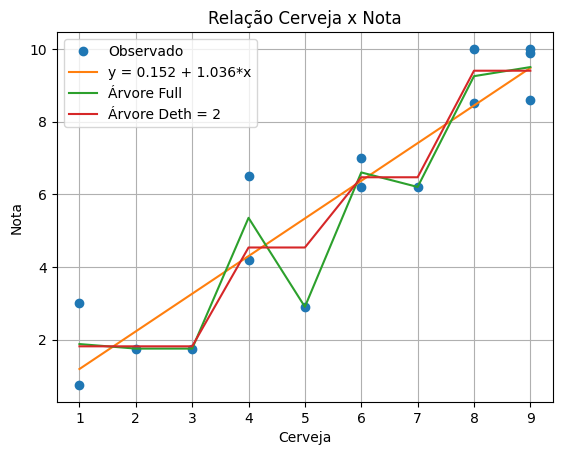

In [27]:
plt.plot(X['cerveja'], y, 'o')
plt.grid(True)
plt.title('Relação Cerveja x Nota')
plt.xlabel("Cerveja")
plt.ylabel("Nota")

plt.plot(X.drop_duplicates()['cerveja'], predict_reg)
plt.plot(X.drop_duplicates()['cerveja'], predict_arvore_full)
plt.plot(X.drop_duplicates()['cerveja'], predict_arvore_d2)

plt.legend(['Observado', 
    f'y = {a:.3f} + {b:.3f}*x', 
    'Árvore Full', 
    'Árvore Deth = 2'])
plt.show()

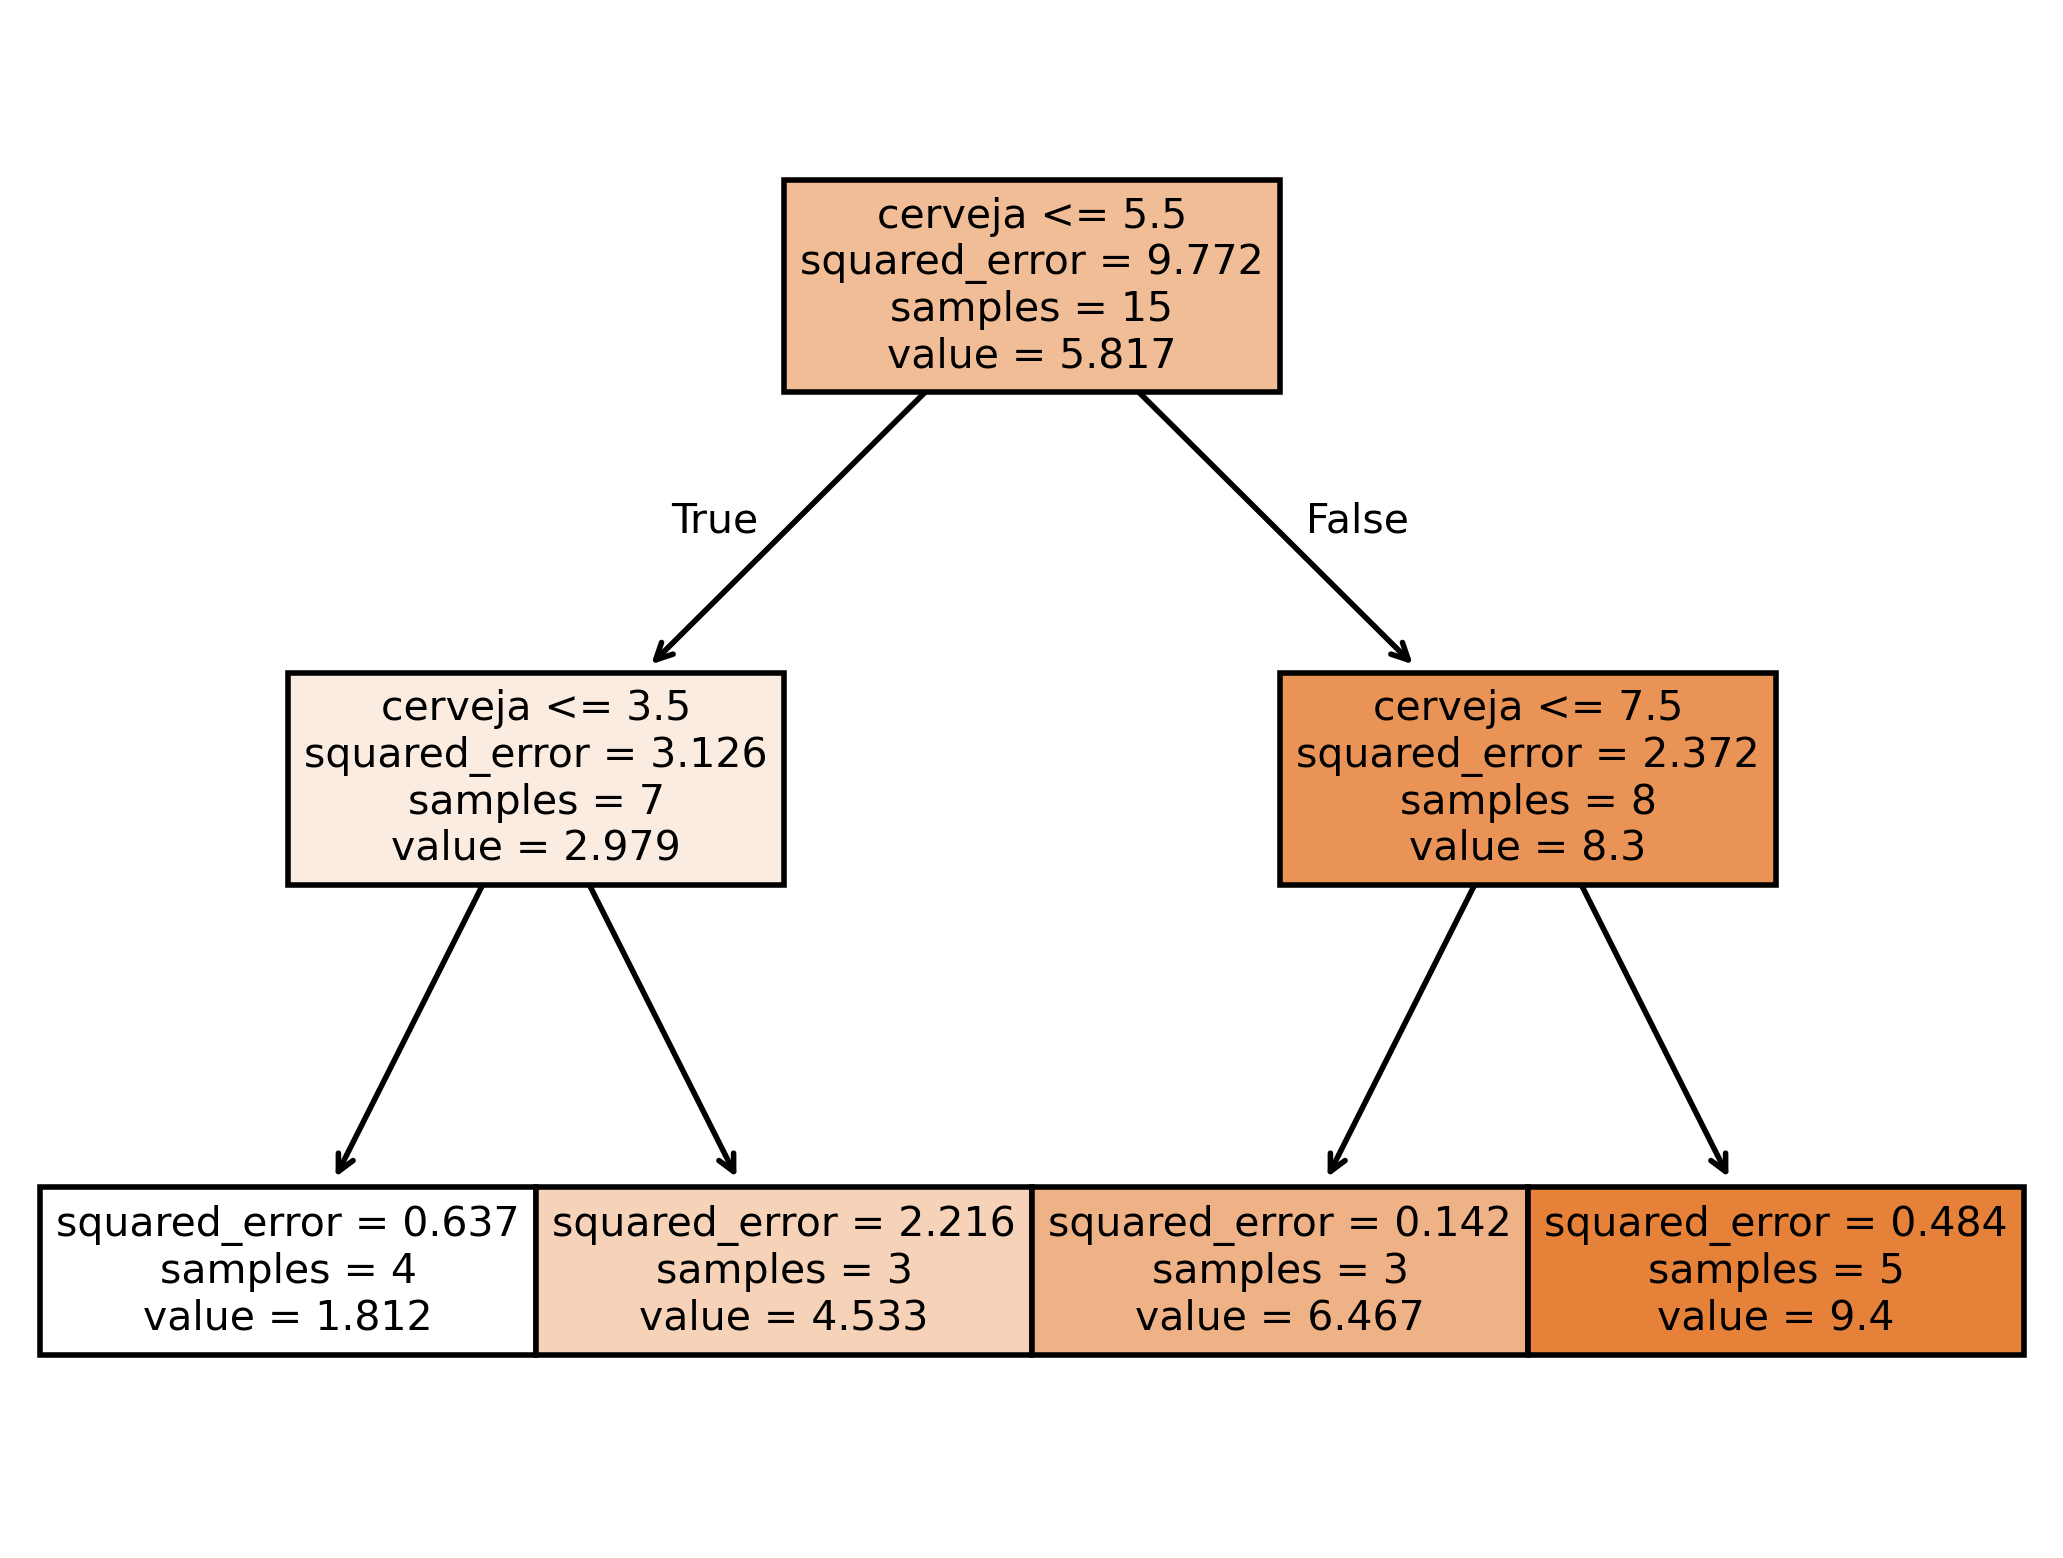

In [30]:
plt.figure(dpi=400)

tree.plot_tree(arvore_d2,
    feature_names=['cerveja'],
    filled=True)
plt.show()

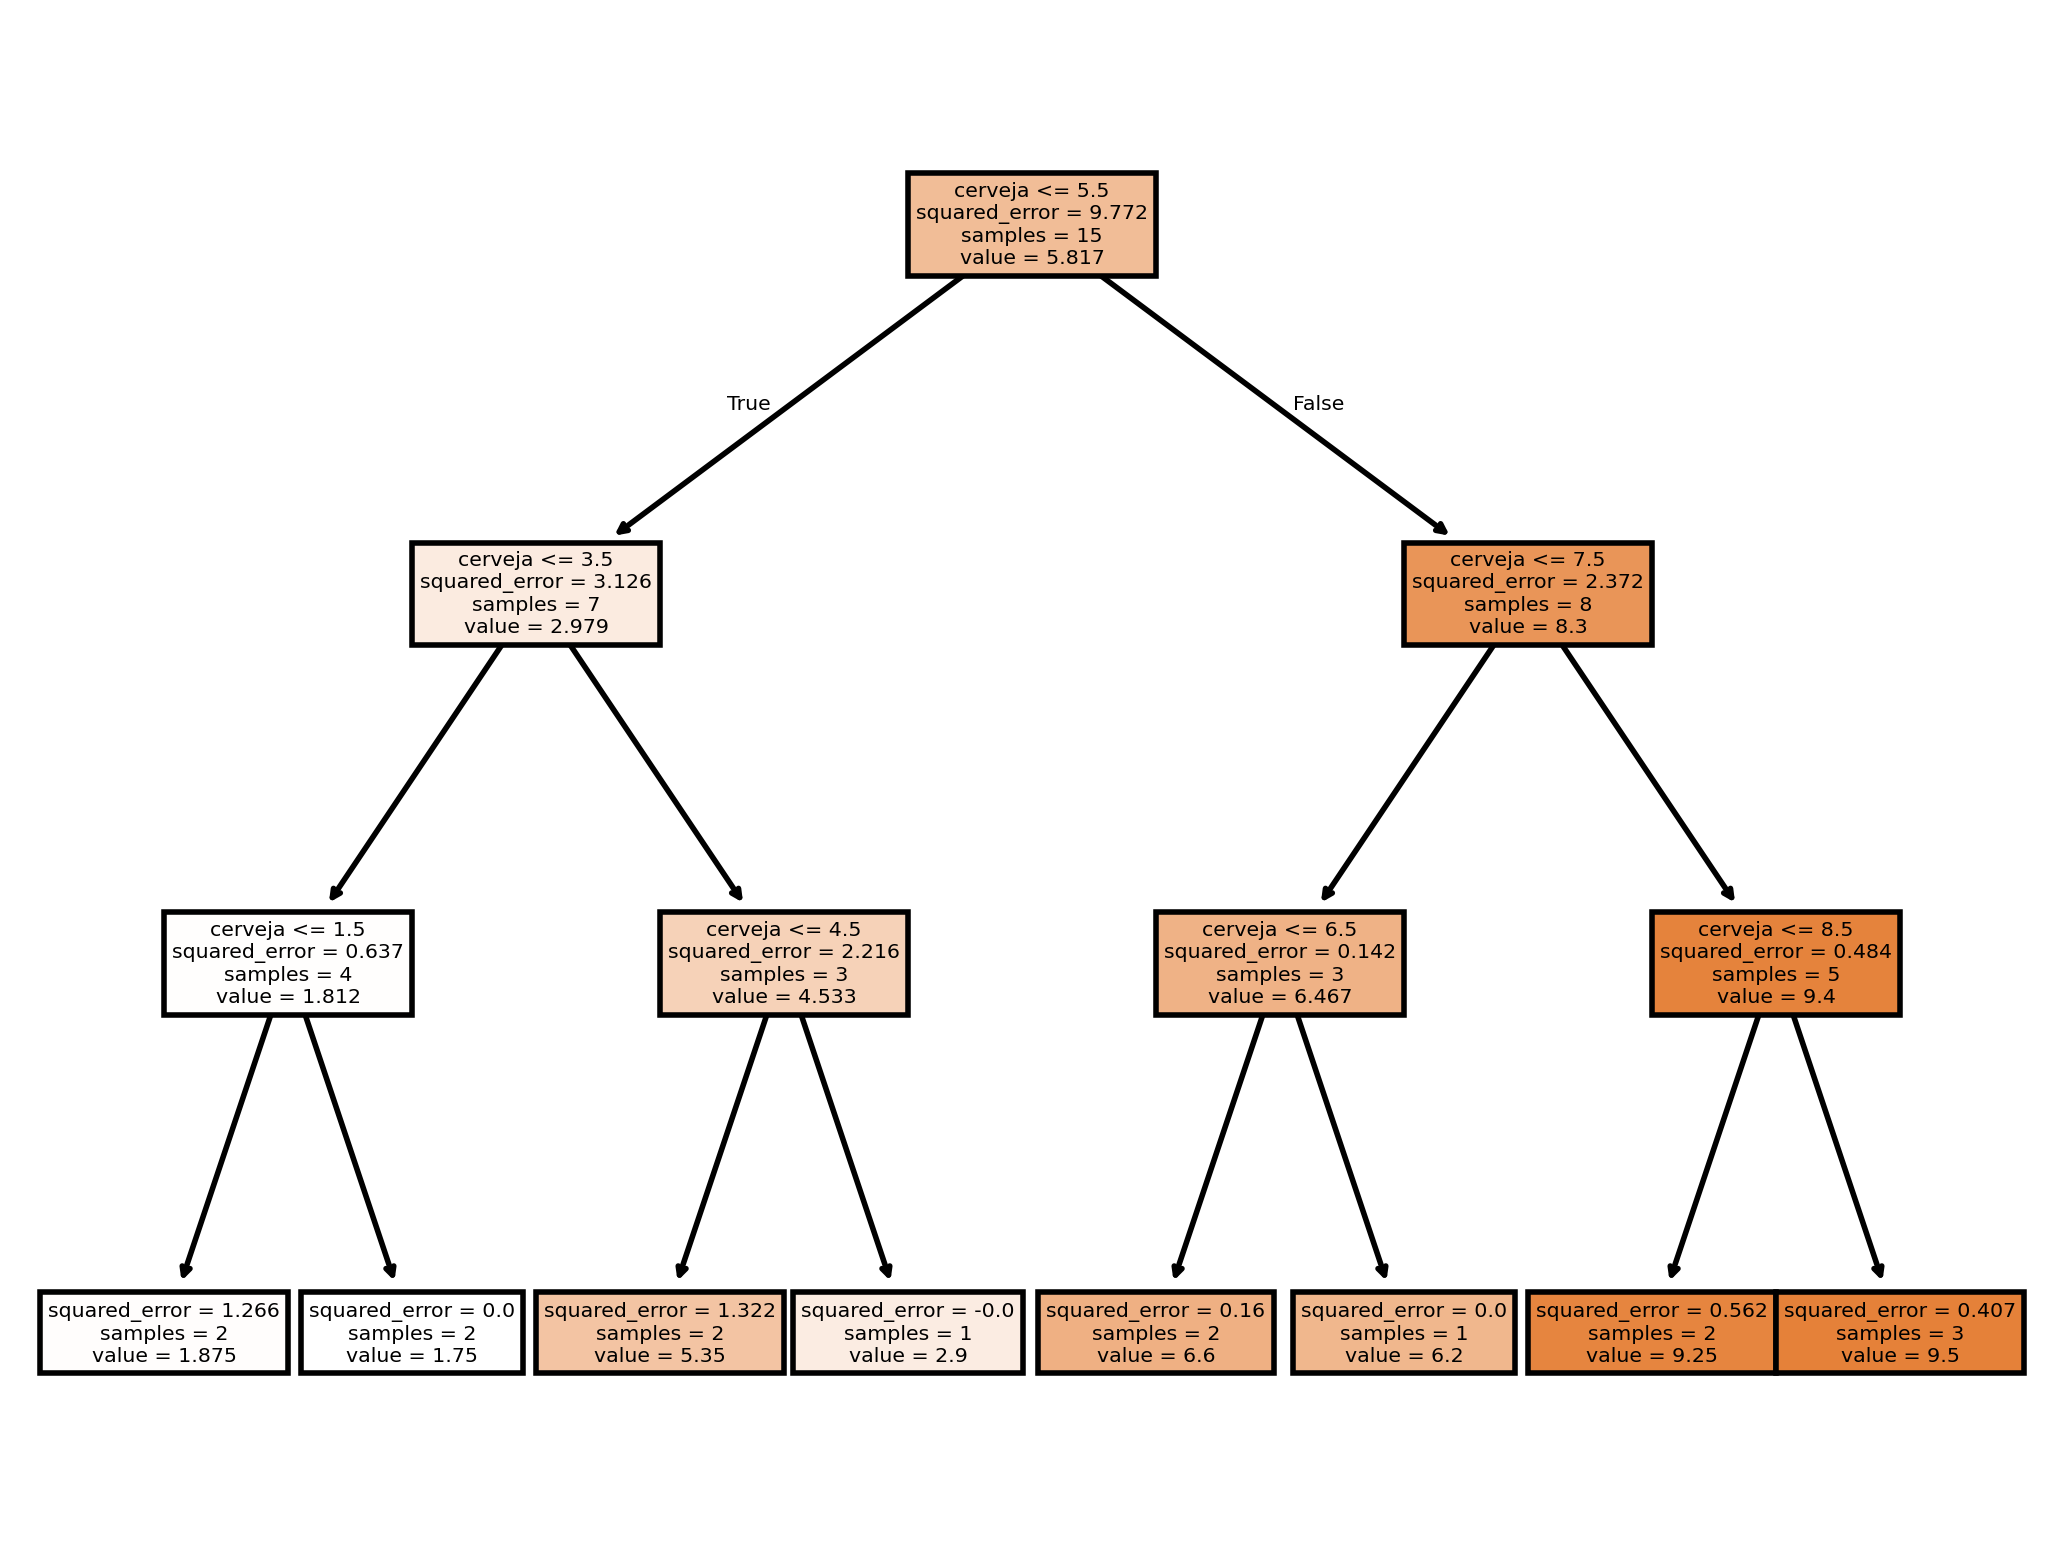

In [31]:
plt.figure(dpi=400)

tree.plot_tree(arvore_full,
    feature_names=['cerveja'],
    filled=True)
plt.show()